In [154]:
from pathlib import Path
import json

import numpy as np
import pandas as pd

from featuregraph.utils._arc_agi import solve_task, plot_arc_agi, get_known_transformations, get_valid_transformations, training_cycle, get_training_pairs, get_block_coordinates, get_candidate_transformations

In [155]:
print(get_training_pairs)
print(training_cycle)

<function get_training_pairs at 0x7cd08ba3bec0>
<function training_cycle at 0x7cd08ba3b920>


In [156]:
def evaluate_task(task):
    predictions = solve_task(task)

    expected_outputs = [
        np.asarray(pair["output"], dtype=int)
        for pair in task["test"]
    ]

    exact = (
        len(predictions) == len(expected_outputs)
        and all(
            np.array_equal(prediction, expected)
            for prediction, expected in zip(
                predictions,
                expected_outputs,
                strict=True,
            )
        )
    )

    return {
        "supported": True,
        "exact": exact,
    }

In [157]:
def evaluate_challenges(challenges):
    results = {}

    for task_id, task in challenges.items():
        try:
            results[task_id] = evaluate_task(task)
        except ValueError as error:
            results[task_id] = {
                "supported": False,
                "exact": False,
                "failure": str(error),
            }

    return results

In [158]:
task_path = Path("../data/arc-agi-2/00576224.json")

with task_path.open(encoding="utf-8") as file:
    task = json.load(file)

challenges = {
    task_path.stem: task,
}

challenges.keys()

dict_keys(['00576224'])

In [159]:
results = evaluate_challenges(challenges)

number_supported = sum(
    result["supported"]
    for result in results.values()
)

number_exact = sum(
    result["exact"]
    for result in results.values()
)

number_fallback = len(results) - number_supported

{
    "tasks": len(results),
    "supported": number_supported,
    "exact_solved": number_exact,
    "supported_but_incorrect": number_supported - number_exact,
    "fallback": number_fallback,
}

{'tasks': 1,
 'supported': 1,
 'exact_solved': 1,
 'supported_but_incorrect': 0,
 'fallback': 0}

In [160]:
evaluation_table = pd.DataFrame.from_dict(
    results,
    orient="index",
).rename_axis("task_id").reset_index()

evaluation_table

,task_id,supported,exact
0,00576224,True,True


In [161]:
training_directory = Path("../../ARC-AGI-2/data/training")

task_paths = sorted(training_directory.glob("*.json"))[:25]

challenges = {}

for task_path in task_paths:
    with task_path.open(encoding="utf-8") as file:
        challenges[task_path.stem] = json.load(file)

len(challenges)

25

In [162]:
list(challenges)[:5]

['00576224', '007bbfb7', '009d5c81', '00d62c1b', '00dbd492']

In [163]:
results = evaluate_challenges(challenges)

In [164]:
number_supported = sum(
    result["supported"]
    for result in results.values()
)

number_exact = sum(
    result["exact"]
    for result in results.values()
)

number_fallback = len(results) - number_supported

{
    "tasks": len(results),
    "supported": number_supported,
    "exact_solved": number_exact,
    "supported_but_incorrect": number_supported - number_exact,
    "fallback": number_fallback,
}

{'tasks': 25,
 'supported': 1,
 'exact_solved': 1,
 'supported_but_incorrect': 0,
 'fallback': 24}

In [165]:
evaluation_table = pd.DataFrame.from_dict(
    results,
    orient="index",
).rename_axis("task_id").reset_index()

evaluation_table

,task_id,supported,exact,failure
0,00576224,True,True,NaN
1,007bbfb7,False,False,Training pairs have no shared operator for blo...
2,009d5c81,False,False,"No operator matched block (0, 0)."
3,00d62c1b,False,False,"No operator matched block (0, 0)."
4,00dbd492,False,False,"No operator matched block (0, 0)."
5,017c7c7b,False,False,Output cannot be divided into input-shaped blo...
6,025d127b,False,False,"No operator matched block (0, 0)."
7,03560426,False,False,"No operator matched block (0, 0)."
8,045e512c,False,False,"No operator matched block (0, 0)."
9,0520fde7,False,False,Output cannot be divided into input-shaped blo...


In [166]:
def categorize_failure(failure):
    if pd.isna(failure):
        return None

    if failure.startswith("No operator matched block"):
        return "no_registered_operator"

    if failure.startswith(
        "Output cannot be divided into input-shaped blocks"
    ):
        return "output_not_input_tiling"

    if failure.startswith(
        "Training pairs produced different instruction-layout shapes"
    ):
        return "inconsistent_layout_shape"

    if failure.startswith("Multiple operators remain"):
        return "operator_ambiguity"

    if failure.startswith(
        "Training pairs have no shared operator"
    ):
        return "no_shared_operator"

    return "other"

In [167]:
evaluation_table["failure_category"] = (
    evaluation_table["failure"].apply(categorize_failure)
)

failure_summary = (
    evaluation_table["failure_category"]
    .value_counts(dropna=False)
    .rename_axis("failure_category")
    .reset_index(name="number_of_tasks")
)

failure_summary

,failure_category,number_of_tasks
0,no_registered_operator,19
1,output_not_input_tiling,4
2,NaN,1
3,no_shared_operator,1


In [168]:
failure_summary["percent_of_tasks"] = (
    100
    * failure_summary["number_of_tasks"]
    / len(evaluation_table)
)

failure_summary

,failure_category,number_of_tasks,percent_of_tasks
0,no_registered_operator,19,76.0
1,output_not_input_tiling,4,16.0
2,NaN,1,4.0
3,no_shared_operator,1,4.0


In [169]:
failure_examples = (
    evaluation_table
    .dropna(subset=["failure_category"])
    .groupby("failure_category")["task_id"]
    .agg(list)
)

failure_examples

failure_category
no_registered_operator     [009d5c81, 00d62c1b, 00dbd492, 025d127b, 03560...
no_shared_operator                                                [007bbfb7]
output_not_input_tiling             [017c7c7b, 0520fde7, 0a1d4ef5, 0b148d64]
Name: task_id, dtype: object

In [170]:
# representative_task_id = failure_examples[
#     "no_registered_operator"
# ][0]

# representative_task = challenges[representative_task_id]

representative_task_id = "007bbfb7"
representative_task = challenges[representative_task_id]

shape_rows = []

for pair_type in ("train", "test"):
    for pair_index, pair in enumerate(
        representative_task[pair_type]
    ):
        input_grid = np.asarray(pair["input"])

        output_grid = (
            np.asarray(pair["output"])
            if "output" in pair
            else None
        )

        shape_rows.append(
            {
                "pair_type": pair_type,
                "pair_index": pair_index,
                "input_shape": input_grid.shape,
                "output_shape": (
                    output_grid.shape
                    if output_grid is not None
                    else None
                ),
                "output_block_rows": (
                    output_grid.shape[0] // input_grid.shape[0]
                    if output_grid is not None
                    else None
                ),
                "output_block_columns": (
                    output_grid.shape[1] // input_grid.shape[1]
                    if output_grid is not None
                    else None
                ),
            }
        )

shape_table = pd.DataFrame(shape_rows)
shape_table

,pair_type,pair_index,input_shape,output_shape,output_block_rows,output_block_columns
0,train,0,"(3, 3)","(9, 9)",3,3
1,train,1,"(3, 3)","(9, 9)",3,3
2,train,2,"(3, 3)","(9, 9)",3,3
3,train,3,"(3, 3)","(9, 9)",3,3
4,train,4,"(3, 3)","(9, 9)",3,3
5,test,0,"(3, 3)","(9, 9)",3,3


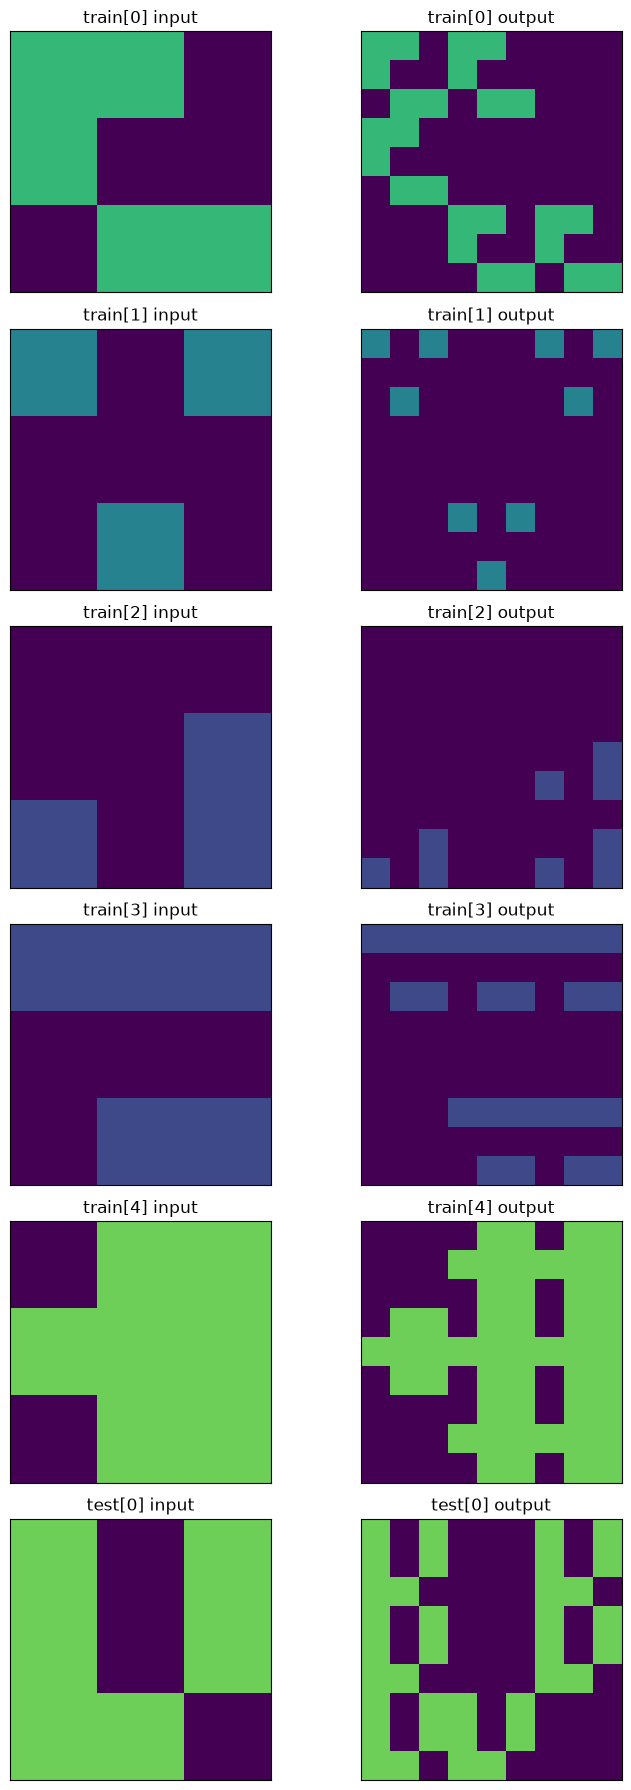

In [171]:
import matplotlib.pyplot as plt


def plot_task(task):
    pairs = [
        (pair_type, pair_index, pair)
        for pair_type in ("train", "test")
        for pair_index, pair in enumerate(task[pair_type])
    ]

    figure, axes = plt.subplots(
        len(pairs),
        2,
        figsize=(8, 3 * len(pairs)),
        squeeze=False,
    )

    for row, (pair_type, pair_index, pair) in enumerate(pairs):
        axes[row, 0].imshow(
            pair["input"],
            vmin=0,
            vmax=9,
            interpolation="nearest",
        )
        axes[row, 0].set_title(
            f"{pair_type}[{pair_index}] input"
        )

        if "output" in pair:
            axes[row, 1].imshow(
                pair["output"],
                vmin=0,
                vmax=9,
                interpolation="nearest",
            )
            axes[row, 1].set_title(
                f"{pair_type}[{pair_index}] output"
            )
        else:
            axes[row, 1].axis("off")

        for axis in axes[row]:
            axis.set_xticks([])
            axis.set_yticks([])

    plt.tight_layout()


plot_task(representative_task)

In [172]:
input_grid = np.asarray(representative_task["train"][1]["input"])

instruction_table = pd.DataFrame({
    "block_row": np.indices(input_grid.shape)[0].ravel(),
    "block_column": np.indices(input_grid.shape)[1].ravel(),
    "input_value": input_grid.ravel(),
})

instruction_table["operator"] = np.where(
    instruction_table["input_value"] == 0,
    "background",
    "copy",
)

instruction_table

,block_row,block_column,input_value,operator
0,0,0,4,copy
1,0,1,0,background
2,0,2,4,copy
3,1,0,0,background
4,1,1,0,background
5,1,2,0,background
6,2,0,0,background
7,2,1,4,copy
8,2,2,0,background


In [173]:
input_grid

array([[4, 0, 4],
       [0, 0, 0],
       [0, 4, 0]])

In [174]:
# plot_arc_agi(
#     input_grid,
#     output=None,
#     manual_output=None,
# )

In [175]:
# transformations = get_known_transformations(input_grid)
# transformations["background"]["value"]

In [176]:
# valid_transformations = get_valid_transformations(input_grid)

# valid_names = [
#     transformation["name"]
#     for transformation in valid_transformations
# ]

# valid_names

In [177]:
# for transformation in valid_transformations:
#     print(transformation["name"])
#     print(transformation["value"])
#     print()

In [178]:
# single_pair = [
#     {
#         "grid": np.asarray(
#             representative_task["train"][1]["input"]
#         ),
#         "output": np.asarray(
#             representative_task["train"][1]["output"]
#         ),
#     }
# ]

In [179]:
# single_pair_layout = training_cycle(single_pair)
# single_pair_layout

In [180]:
print("get_training_pairs:", get_training_pairs)
print("training_cycle:", training_cycle)
print("representative_task:", representative_task_id)

get_training_pairs: <function get_training_pairs at 0x7cd08ba3bec0>
training_cycle: <function training_cycle at 0x7cd08ba3b920>
representative_task: 007bbfb7


In [181]:
training_pairs = get_training_pairs(representative_task)
training_pairs

[{'grid': array([[6, 6, 0],
         [6, 0, 0],
         [0, 6, 6]]),
  'output': array([[6, 6, 0, 6, 6, 0, 0, 0, 0],
         [6, 0, 0, 6, 0, 0, 0, 0, 0],
         [0, 6, 6, 0, 6, 6, 0, 0, 0],
         [6, 6, 0, 0, 0, 0, 0, 0, 0],
         [6, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 6, 6, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 6, 6, 0, 6, 6, 0],
         [0, 0, 0, 6, 0, 0, 6, 0, 0],
         [0, 0, 0, 0, 6, 6, 0, 6, 6]])},
 {'grid': array([[4, 0, 4],
         [0, 0, 0],
         [0, 4, 0]]),
  'output': array([[4, 0, 4, 0, 0, 0, 4, 0, 4],
         [0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 4, 0, 0, 0, 0, 0, 4, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 4, 0, 4, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 4, 0, 0, 0, 0]])},
 {'grid': array([[0, 0, 0],
         [0, 0, 2],
         [2, 0, 2]]),
  'output': array([[0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0

In [182]:
training_pairs = get_training_pairs(representative_task)
# instruction_layout = training_cycle(training_pairs)

In [183]:
training_pairs[0]

{'grid': array([[6, 6, 0],
        [6, 0, 0],
        [0, 6, 6]]),
 'output': array([[6, 6, 0, 6, 6, 0, 0, 0, 0],
        [6, 0, 0, 6, 0, 0, 0, 0, 0],
        [0, 6, 6, 0, 6, 6, 0, 0, 0],
        [6, 6, 0, 0, 0, 0, 0, 0, 0],
        [6, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 6, 6, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 6, 6, 0, 6, 6, 0],
        [0, 0, 0, 6, 0, 0, 6, 0, 0],
        [0, 0, 0, 0, 6, 6, 0, 6, 6]])}

In [184]:
training_pairs[1]

{'grid': array([[4, 0, 4],
        [0, 0, 0],
        [0, 4, 0]]),
 'output': array([[4, 0, 4, 0, 0, 0, 4, 0, 4],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 4, 0, 0, 0, 0, 0, 4, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 4, 0, 4, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 4, 0, 0, 0, 0]])}

In [185]:
training_pairs[2]

{'grid': array([[0, 0, 0],
        [0, 0, 2],
        [2, 0, 2]]),
 'output': array([[0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 2],
        [0, 0, 0, 0, 0, 0, 2, 0, 2],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 2, 0, 0, 0, 0, 0, 2],
        [2, 0, 2, 0, 0, 0, 2, 0, 2]])}

In [186]:
instruction_layout = training_cycle([training_pairs[0]])

In [187]:
instruction_layout

array([['copy', 'copy', 'background'],
       ['copy', 'background', 'background'],
       ['background', 'copy', 'copy']], dtype=object)

In [202]:
# instruction_layout = training_cycle([training_pairs[1]])

In [189]:
instruction_layout = training_cycle([training_pairs[2]])

In [190]:
instruction_layout

array([['background', 'background', 'background'],
       ['background', 'background', 'copy'],
       ['copy', 'background', 'copy']], dtype=object)

In [198]:
valid_transformations = get_valid_transformations(training_pairs[1]['grid'])
block_coordinates = get_block_coordinates((3,3), (9,9))
candidate_transformations = np.array([
            get_candidate_transformations(
                transformation["value"],
                block_coordinates,
            )
            for transformation in valid_transformations
        ]).T


In [199]:
candidate_transformations

array([[4, 4, 0, 4, 0, 0, 0],
       [0, 0, 4, 0, 4, 0, 0],
       [4, 4, 0, 0, 0, 4, 0],
       [4, 4, 0, 4, 0, 0, 0],
       [0, 0, 4, 0, 4, 0, 0],
       [4, 4, 0, 0, 0, 4, 0],
       [4, 4, 0, 4, 0, 0, 0],
       [0, 0, 4, 0, 4, 0, 0],
       [4, 4, 0, 0, 0, 4, 0],
       [0, 0, 0, 0, 0, 4, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 4, 0, 0, 0],
       [0, 0, 0, 0, 0, 4, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 4, 0, 0, 0],
       [0, 0, 0, 0, 0, 4, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 4, 0, 0, 0],
       [0, 0, 4, 4, 4, 0, 0],
       [4, 4, 0, 0, 0, 0, 0],
       [0, 0, 4, 0, 4, 4, 0],
       [0, 0, 4, 4, 4, 0, 0],
       [4, 4, 0, 0, 0, 0, 0],
       [0, 0, 4, 0, 4, 4, 0],
       [0, 0, 4, 4, 4, 0, 0],
       [4, 4, 0, 0, 0, 0, 0],
       [0, 0, 4, 0, 4, 4, 0],
       [4, 4, 0, 4, 0, 0, 0],
       [0, 0, 4, 0, 4, 0, 0],
       [4, 4, 0, 0, 0, 4, 0],
       [4, 4, 0, 4, 0, 0, 0],
       [0, 0, 4, 0, 4, 0, 0],
       [4, 4, 0, 0, 0, 4, 0],
       [4,

In [200]:
operator_names = [
    transformation["name"]
    for transformation in valid_transformations
]

operator_names

['copy',
 'flip_horizontal',
 'flip_vertical',
 'rotate_90',
 'rotate_180',
 'rotate_270',
 'background']

In [201]:
column_equality = np.array([
    [
        np.array_equal(
            candidate_transformations[:, left],
            candidate_transformations[:, right],
        )
        for right in range(len(operator_names))
    ]
    for left in range(len(operator_names))
])

column_equality_table = pd.DataFrame(
    column_equality,
    index=operator_names,
    columns=operator_names,
)

column_equality_table

,copy,flip_horizontal,flip_vertical,rotate_90,rotate_180,rotate_270,background
copy,True,True,False,False,False,False,False
flip_horizontal,True,True,False,False,False,False,False
flip_vertical,False,False,True,False,True,False,False
rotate_90,False,False,False,True,False,False,False
rotate_180,False,False,True,False,True,False,False
rotate_270,False,False,False,False,False,True,False
background,False,False,False,False,False,False,True


In [203]:
training_pairs[1]

{'grid': array([[4, 0, 4],
        [0, 0, 0],
        [0, 4, 0]]),
 'output': array([[4, 0, 4, 0, 0, 0, 4, 0, 4],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 4, 0, 0, 0, 0, 0, 4, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 4, 0, 4, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 4, 0, 0, 0, 0]])}

In [204]:
training_pairs

[{'grid': array([[6, 6, 0],
         [6, 0, 0],
         [0, 6, 6]]),
  'output': array([[6, 6, 0, 6, 6, 0, 0, 0, 0],
         [6, 0, 0, 6, 0, 0, 0, 0, 0],
         [0, 6, 6, 0, 6, 6, 0, 0, 0],
         [6, 6, 0, 0, 0, 0, 0, 0, 0],
         [6, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 6, 6, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 6, 6, 0, 6, 6, 0],
         [0, 0, 0, 6, 0, 0, 6, 0, 0],
         [0, 0, 0, 0, 6, 6, 0, 6, 6]])},
 {'grid': array([[4, 0, 4],
         [0, 0, 0],
         [0, 4, 0]]),
  'output': array([[4, 0, 4, 0, 0, 0, 4, 0, 4],
         [0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 4, 0, 0, 0, 0, 0, 4, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 4, 0, 4, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 4, 0, 0, 0, 0]])},
 {'grid': array([[0, 0, 0],
         [0, 0, 2],
         [2, 0, 2]]),
  'output': array([[0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0